In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import Perceptron
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [22]:
# ==========================================
# ШАГ 1: Загрузка данных
# ==========================================
df_kaggle = pd.read_csv('IT_Job_Roles_Skills.csv', encoding='latin1')
df_custom = pd.read_csv('real_dataset_v2 (1).csv')

In [23]:
# ==========================================
# ШАГ 2: Маппинг и стандартизация категорий
# ==========================================
def categorize_job(title):
    title = str(title).lower()
    if any(k in title for k in ['data', 'ai', 'machine learning', 'ml', 'artificial intelligence', 'analyst', 'analytics']):
        return 'Data Science & Analytics'
    elif any(k in title for k in ['devops', 'build', 'release', 'jenkins', 'ansible', 'chef', 'elk', 'sre', 'site reliability', 'kubernetes', 'docker']):
        return 'DevOps & Infrastructure'
    elif any(k in title for k in ['frontend', 'web', 'ui', 'ux', 'react', 'angular', 'vue', 'javascript']):
        return 'Frontend Development'
    elif any(k in title for k in ['security', 'cyber', 'information security']):
        return 'Cybersecurity'
    elif any(k in title for k in ['cloud', 'aws', 'azure', 'gcp']):
        return 'Cloud Engineering'
    elif any(k in title for k in ['qa', 'test', 'quality', 'automation']):
        return 'QA & Testing'
    elif any(k in title for k in ['admin', 'administrator', 'sysadmin', 'support']):
        return 'System Administration'
    elif any(k in title for k in ['manager', 'leader', 'scrum', 'project', 'product', 'director', 'head']):
        return 'Management & Operations'
    elif any(k in title for k in ['architect', 'architecture']):
        return 'Architecture'
    elif any(k in title for k in ['backend', 'software', 'developer', 'programmer', 'engineer', 'java', 'python', 'c++', 'api']):
        return 'Software Engineering'
    else:
        return 'Other IT Role'

df_kaggle['Target_Role'] = df_kaggle['Job Title'].apply(categorize_job)
df_kaggle_clean = df_kaggle[['Skills', 'Target_Role']].dropna().copy()
df_kaggle_clean.rename(columns={'Skills': 'Skills_List'}, inplace=True)

category_mapping = {
    'Data Scientist': 'Data Science & Analytics',
    'Data Analyst': 'Data Science & Analytics',
    'Software Engineer': 'Software Engineering',
    'Frontend Developer': 'Frontend Development',
    'DevOps Engineer': 'DevOps & Infrastructure'
}
df_custom['Target_Role'] = df_custom['category'].map(category_mapping)
df_custom_clean = df_custom[['job_skill_set', 'Target_Role']].dropna().copy()
df_custom_clean.rename(columns={'job_skill_set': 'Skills_List'}, inplace=True)

df_merged = pd.concat([df_kaggle_clean, df_custom_clean], ignore_index=True)

counts = df_merged['Target_Role'].value_counts()
df_merged = df_merged[df_merged['Target_Role'].isin(counts[counts > 10].index)]

In [24]:
# ==========================================
# ШАГ 3: Векторизация (Feature Engineering)
# ==========================================
X = df_merged['Skills_List']
y = df_merged['Target_Role']

vectorizer = TfidfVectorizer(stop_words='english', max_features=500)
X_vec = vectorizer.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_vec, y, test_size=0.2, random_state=42)

In [25]:
# ==========================================
# ШАГ 4: Обучение алгоритмов (только из лекции)
# ==========================================
models = {
    'k-NN': KNeighborsClassifier(n_neighbors=5),
    # Добавляем class_weight='balanced'
    'Perceptron': Perceptron(class_weight='balanced', random_state=42),
    'SVM (Linear)': SVC(kernel='linear', class_weight='balanced', random_state=42)
}

accuracies = {}
best_model = None
best_acc = 0

print("--- Результаты оценки моделей ---\n")
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies[name] = acc
    print(f"{name} Accuracy: {acc:.2f}")

    if acc > best_acc:
        best_acc = acc
        best_model = model

--- Результаты оценки моделей ---

k-NN Accuracy: 0.69
Perceptron Accuracy: 0.75
SVM (Linear) Accuracy: 0.77


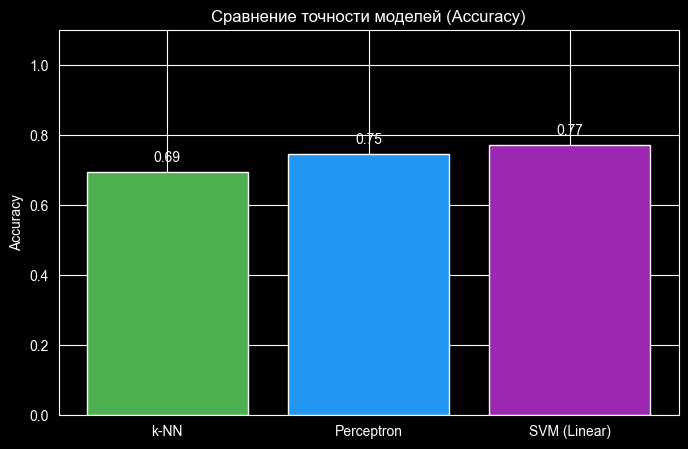

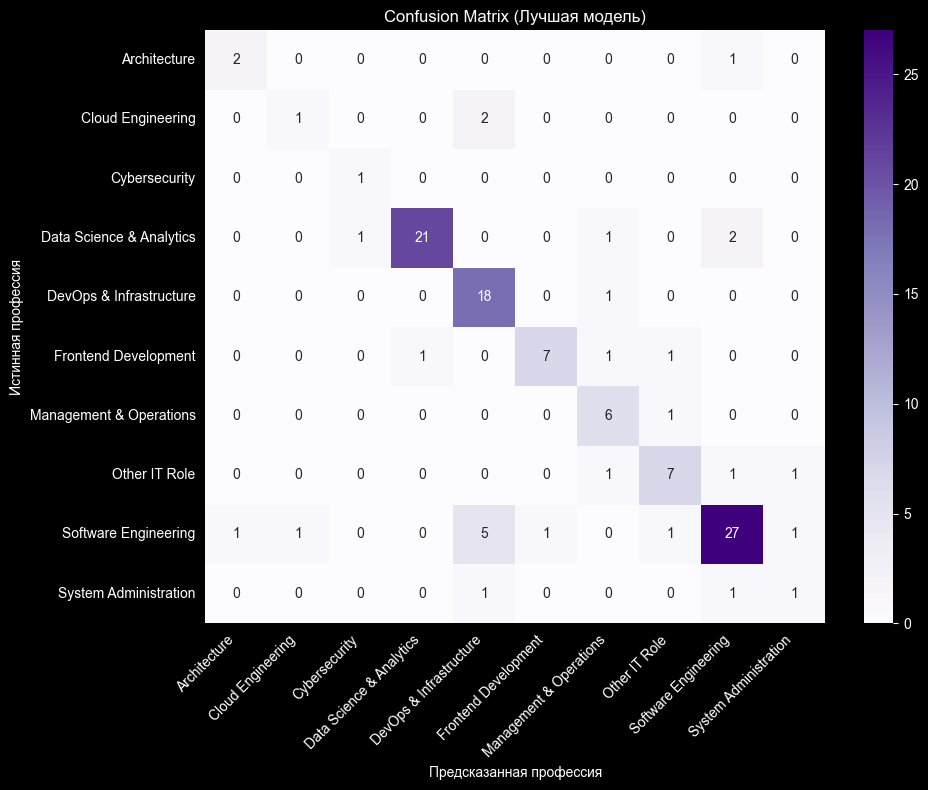

In [26]:
# ==========================================
# ШАГ 5: Визуализация
# ==========================================
plt.figure(figsize=(8, 5))
bars = plt.bar(accuracies.keys(), accuracies.values(), color=['#4CAF50', '#2196F3', '#9C27B0'])
plt.title('Сравнение точности моделей (Accuracy)')
plt.ylabel('Accuracy')
plt.ylim(0, 1.1)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, round(yval, 2), ha='center', va='bottom')
plt.show()

y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.title('Confusion Matrix (Лучшая модель)')
plt.ylabel('Истинная профессия')
plt.xlabel('Предсказанная профессия')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [27]:
# ==========================================
# ШАГ 6: Inference
# ==========================================
def predict_job_role(skills_text):
    skills_vec = vectorizer.transform([skills_text])
    prediction = best_model.predict(skills_vec)
    return prediction[0]

print("\n--- Тестируем систему ---")
user_skills = input("Введите ваши навыки через запятую (например: Kubernetes, AWS, Docker): ")
predicted_role = predict_job_role(user_skills)
print(f"👉 Предсказанная специальность: {predicted_role}")


--- Тестируем систему ---
👉 Предсказанная специальность: Software Engineering
